In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
df = pd.read_csv("/Users/aniket/smart-expense-ml/Data/train.csv")

In [7]:
df.head()

,Transaction_Text,Label
0,Swiggy order payment | Ref:0f8f77bb | Amount: ...,Food
1,Ola cab fare | Ref:8b98e0de | Amount: INR 7019.92,Travel
2,Dominos pizza order | Ref:2cfbbdd3 | Amount: I...,Food
3,Amazon online shopping | Ref:68e9a9f2 | Amount...,Shopping
4,Swiggy order payment | Ref:c49e5e14 | Amount: ...,Food


In [8]:
df.shape

(10000, 2)

In [9]:
df.columns

Index(['Transaction_Text', 'Label'], dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction_Text  10000 non-null  str  
 1   Label             10000 non-null  str  
dtypes: str(2)
memory usage: 801.3 KB


In [11]:
df.isnull().sum()

Transaction_Text    0
Label               0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Label"].value_counts()

Label
Investment    2041
Shopping      2034
EMI           1981
Food          1978
Travel        1966
Name: count, dtype: int64

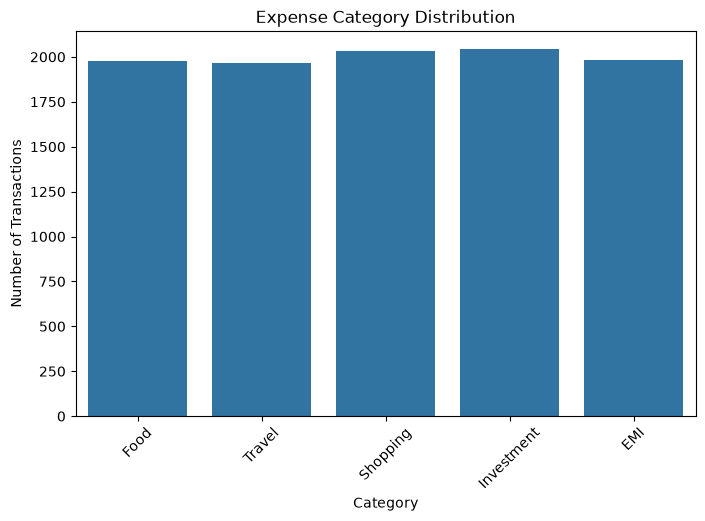

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Label")

plt.title("Expense Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [15]:
df.columns = df.columns.str.strip()

In [16]:
df = df.dropna(subset=["Transaction_Text", "Label"])

In [17]:
df = df.drop_duplicates()

In [18]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [19]:
df["clean_text"] = df["Transaction_Text"].apply(clean_text)

In [20]:
df[["Transaction_Text", "clean_text", "Label"]].head(10)

,Transaction_Text,clean_text,Label
0,Swiggy order payment | Ref:0f8f77bb | Amount: ...,swiggy order payment refffbb amount inr,Food
1,Ola cab fare | Ref:8b98e0de | Amount: INR 7019.92,ola cab fare refbede amount inr,Travel
2,Dominos pizza order | Ref:2cfbbdd3 | Amount: I...,dominos pizza order refcfbbdd amount inr,Food
3,Amazon online shopping | Ref:68e9a9f2 | Amount...,amazon online shopping refeaf amount inr,Shopping
4,Swiggy order payment | Ref:c49e5e14 | Amount: ...,swiggy order payment refcee amount inr,Food
5,Petrol pump fuel payment | Ref:06a7106d | Amou...,petrol pump fuel payment refad amount inr,Travel
6,Flipkart electronics purchase | Ref:2d2f3ce4 |...,flipkart electronics purchase refdfce amount inr,Shopping
7,Reliance Digital purchase | Ref:b11436df | Amo...,reliance digital purchase refbdf amount inr,Shopping
8,Myntra clothing order | Ref:aee7ac2c | Amount:...,myntra clothing order refaeeacc amount inr,Shopping
9,McDonald's meal payment | Ref:24158147 | Amoun...,mcdonalds meal payment ref amount inr,Food


In [21]:
df.to_csv("../data/cleaned_expenses.csv", index=False)